In [9]:
# Install dependencies
%pip install ultralytics
%pip install opencv-python
%pip install matplotlib
%pip install numpy
%pip install pillow
%pip install pyyaml
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [13]:
import torch
import torchvision
import ultralytics

print("Python:", __import__("sys").version)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Ultralytics:", ultralytics.__version__)
print("MPS:", torch.backends.mps.is_available())

Python: 3.14.6 (main, Jun 10 2026, 10:03:53) [Clang 21.0.0 (clang-2100.0.123.102)]
Torch: 2.13.0
Torchvision: 0.28.0
Ultralytics: 8.4.123
MPS: True


In [10]:
#Dataset
import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

import yaml

with open('BrahmiGlyphData/data.yaml', 'r') as f:
    print(yaml.safe_load(f))

{'names': ['brahmi_glyph'], 'path': 'BrahmiGlyphData', 'train': 'images/train', 'val': 'images/val', 'nc': 1}


In [12]:
from pathlib import Path

labels_dir = Path("BrahmiGlyphData/labels/train")

bad_files = []

for label_file in labels_dir.glob("*.txt"):
    lines = label_file.read_text().strip().splitlines()

    for line_no, line in enumerate(lines, 1):
        parts = line.split()

        if len(parts) != 5:
            bad_files.append(
                (label_file.name, line_no, "wrong number of values", line)
            )
            continue

        try:
            cls, x, y, w, h = map(float, parts)
        except ValueError:
            bad_files.append(
                (label_file.name, line_no, "non-numeric value", line)
            )
            continue

        if cls < 0 or cls != int(cls):
            bad_files.append(
                (label_file.name, line_no, "invalid class", line)
            )

        if not (0 <= x <= 1 and 0 <= y <= 1 and
                0 < w <= 1 and 0 < h <= 1):
            bad_files.append(
                (label_file.name, line_no, "invalid bbox", line)
            )

print(f"Bad annotations found: {len(bad_files)}")

for item in bad_files[:20]:
    print(item)

Bad annotations found: 0


In [14]:
#Yolo Model Training
from ultralytics import YOLO
import torch
from pathlib import Path

DATA_YAML = 'BrahmiGlyphData/data.yaml'

PROJECT_NAME = 'brahmi_detection'
EXPERIMENT_NAME = 'yolov8n_grainy_manuscripts'

TRAINED_MODEL_DIR = Path('trained_model')
TRAINED_MODEL_DIR.mkdir(exist_ok=True)

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Training on: {device}")

model = YOLO('model/yolov8n.pt')

# TRAINING
results = model.train(
    data=DATA_YAML,
    epochs=300,
    patience=50,
    imgsz=640,
    batch=8,
    workers=4,
    device=device,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=5,
    dropout=0.2,

    hsv_h=0.02,
    hsv_s=0.3,
    hsv_v=0.6,
    degrees=15.0,
    translate=0.15,
    scale=0.6,
    shear=5.0,
    perspective=0.0003,
    flipud=0.0,
    fliplr=0.5,

    mosaic=0.8,
    mixup=0.15,
    copy_paste=0.3,

    close_mosaic=20,
    amp=True,

    project=PROJECT_NAME,
    name=EXPERIMENT_NAME,
    save=True,
    save_period=20,
    exist_ok=True,

    val=True,
    plots=True,

    multi_scale=False,
    overlap_mask=True,
    mask_ratio=4,
)

print("\n" + "=" * 50)
print("TRAINING COMPLETE")
print("=" * 50)

#  VALIDATE 
print("\nRunning validation...")
metrics = model.val()
print("\n" + "=" * 50)
print("VALIDATION RESULTS")
print("=" * 50)

print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

# SAVE BEST MODEL 
best_weights = (Path(PROJECT_NAME)/ 'weights'/ 'best.pt')
final_weights = TRAINED_MODEL_DIR / 'best.pt'

if best_weights.exists():
    shutil.copy2(best_weights, final_weights)
    print(f"\n✓ Best model saved to: {final_weights}")
else:
    print(f"\n⚠ Could not find: {best_weights}")

Training on: mps
New https://pypi.org/project/ultralytics/8.4.124 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.123 🚀 Python-3.14.6 torch-2.13.0 MPS (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=BrahmiGlyphData/data.yaml, degrees=15.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.3, hsv_v=0.6, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, m

/Users/anusha/Brahmi/4.code/venv/lib/python3.14/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/anusha/Brahmi/4.code/venv/lib/python3.14/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/run

      1/300      16.6G      2.646      3.317      1.676       1812        640: 100% ━━━━━━━━━━━━ 4/4 10.9s/it 43.7s.6s5
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.6it/s 0.4s
                   all          3        545      0.236      0.389       0.18     0.0428

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/anusha/Brahmi/4.code/venv/lib/python3.14/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/anusha/Brahmi/4.code/venv/lib/python3.14/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/run

      2/300      14.8G      2.514       2.91       1.47       3108        640: 100% ━━━━━━━━━━━━ 4/4 2.0s/it 7.9s0.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.5it/s 0.4s
                   all          3        545      0.313      0.517      0.279     0.0707

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/300      14.9G      2.488      2.805      1.363       3482        640: 0% ──────────── 0/4  1.1s

...

    249/300      16.8G      1.576     0.7783      1.036       1881        640: 100% ━━━━━━━━━━━━ 4/4 2.2s/it 8.9s1.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.4it/s 0.3s
                   all          3        545      0.888      0.921      0.944      0.495

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/anusha/Brahmi/4.code/venv/lib/python3.14/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/anusha/Brahmi/4.code/venv/lib/python3.14/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/run

    250/300      16.8G      1.586     0.7631      1.019       1809        640: 100% ━━━━━━━━━━━━ 4/4 3.4s/it 13.6s1.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.8it/s 0.3s
                   all          3        545      0.888      0.921      0.944      0.495

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/anusha/Brahmi/4.code/venv/lib/python3.14/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/anusha/Brahmi/4.code/venv/lib/python3.14/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/run

    251/300      16.8G      1.523     0.7519      1.013       1726        640: 100% ━━━━━━━━━━━━ 4/4 2.6s/it 10.3s1.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.6it/s 0.3s
                   all          3        545      0.895      0.922      0.941      0.494
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 201, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

251 epochs completed in 1.431 hours.
Optimizer stripped from /Users/anusha/Brahmi/4.code/runs/detect/brahmi_detection/yolov8n_grainy_manuscripts/weights/last.pt, 6.3MB
Optimizer stripped from /Users/anusha/Brahmi/4.code/runs/detect/brahmi_detection/yolov8n_grainy_manuscripts/weights/best.pt, 6.3MB

Validating /Users/anusha/Brahmi/4.code/runs/detect/brahmi_detection/yolov8n_grainy_manu

QUALITATIVE VALIDATION - GLYPH DETECTION
Running predictions and drawing bounding boxes...

Processing: MacchilipatnamPlatesVijyaditya_844.png
Detected 156 glyphs
Saved to: brahmi_detection/visualizations/MacchilipatnamPlatesVijyaditya_844_annotated.jpg
Processing: VizagapatnamCopperPlate_254.png
Detected 275 glyphs
Saved to: brahmi_detection/visualizations/VizagapatnamCopperPlate_254_annotated.jpg
Processing: 641.png
Detected 183 glyphs
Saved to: brahmi_detection/visualizations/641_annotated.jpg

All visualizations saved to:
  brahmi_detection/visualizations

Displaying sample: MacchilipatnamPlatesVijyaditya_844_annotated.jpg


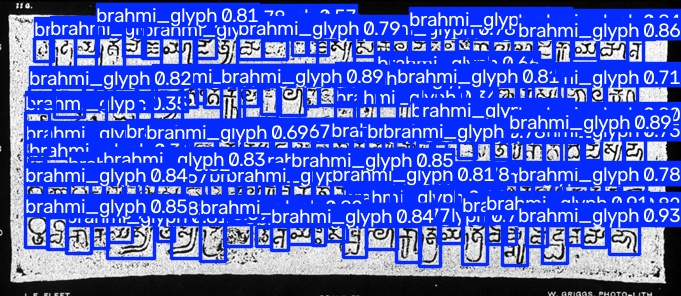

In [16]:
#Training Results
import cv2
from pathlib import Path
from IPython.display import Image, display

print("QUALITATIVE VALIDATION - GLYPH DETECTION")
print("=" * 60)

val_images_path = Path('BrahmiGlyphData/images/val')
val_images = list(val_images_path.glob('*.[jp][pn][g]*'))

if val_images:
    print("Running predictions and drawing bounding boxes...\n")
    output_dir = (Path(PROJECT_NAME) / 'visualizations')
    output_dir.mkdir(parents=True, exist_ok=True)

    for img_path in val_images:
        print(f"Processing: {img_path.name}")
        results = model.predict(
            source=str(img_path),
            conf=0.25,
            iou=0.45,
            max_det=1000,
            save=False,
            verbose=False
        )
        result = results[0]
        img_with_boxes = result.plot(
            line_width=2,
            font_size=0.5,
            conf=True,
            labels=True
        )
        output_path = (output_dir/ f'{img_path.stem}_annotated.jpg')
        cv2.imwrite(str(output_path), img_with_boxes)
        num_detections = len(result.boxes)

        print(f"Detected {num_detections} glyphs")
        print(f"Saved to: {output_path}")

    print(f"\n{'=' * 50}")
    print("All visualizations saved to:")
    print(f"  {output_dir}")
    print(f"{'=' * 50}")

    # Display one example
    first_viz = list(
        output_dir.glob('*_annotated.jpg')
    )[0]

    print(f"\nDisplaying sample: {first_viz.name}")

    display(
        Image(
            filename=str(first_viz),
            width=900
        )
    )

else:
    print("⚠ No validation images found!")

In [21]:
# ==================== TRAINING & VALIDATION SUMMARY ====================

from pathlib import Path
import pandas as pd

RESULTS_CSV = (Path("runs/detect")/ PROJECT_NAME/ EXPERIMENT_NAME/ "results.csv")

df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()

best_idx = df["metrics/mAP50-95(B)"].idxmax()
best = df.loc[best_idx]

summary = {
    "best_epoch": int(best["epoch"]) + 1,
    "box_loss": best["train/box_loss"],
    "class_loss": best["train/cls_loss"],
    "dfl_loss": best["train/dfl_loss"],
    "precision": best["metrics/precision(B)"],
    "recall": best["metrics/recall(B)"],
    "mAP50": best["metrics/mAP50(B)"],
    "mAP50_95": best["metrics/mAP50-95(B)"],
    "total_epochs": len(df),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv("training_summary.csv", index=False)

print("=" * 70)
print("BRAHMI GLYPH DETECTION - TRAINING & VALIDATION SUMMARY")
print("=" * 70)

print(f"\nBest Epoch       : {summary['best_epoch']}")

print("\nTRAINING LOSSES")
print("-" * 70)
print(f"Box Loss         : {summary['box_loss']:.4f}")
print(f"Class Loss       : {summary['class_loss']:.4f}")
print(f"DFL Loss         : {summary['dfl_loss']:.4f}")

print("\nVALIDATION PERFORMANCE")
print("-" * 70)
print(f"Precision        : {summary['precision']:.4f}")
print(f"Recall           : {summary['recall']:.4f}")
print(f"mAP@50           : {summary['mAP50']:.4f}")
print(f"mAP@50-95        : {summary['mAP50_95']:.4f}")

print("\nTRAINING SUMMARY")
print("-" * 70)
print(f"Total Epochs     : {summary['total_epochs']}")
print("Best Criterion   : mAP@50-95")

print("\n✓ Saved to: training_summary.csv")
print("=" * 70)

BRAHMI GLYPH DETECTION - TRAINING & VALIDATION SUMMARY

Best Epoch       : 202

TRAINING LOSSES
----------------------------------------------------------------------
Box Loss         : 1.5685
Class Loss       : 0.7902
DFL Loss         : 1.0235

VALIDATION PERFORMANCE
----------------------------------------------------------------------
Precision        : 0.8959
Recall           : 0.9161
mAP@50           : 0.9551
mAP@50-95        : 0.5210

TRAINING SUMMARY
----------------------------------------------------------------------
Total Epochs     : 251
Best Criterion   : mAP@50-95

✓ Saved to: training_summary.csv


In [19]:
#Glyph Detection and Extraction
print("\n" + "=" * 50)
print("EXTRACTING INDIVIDUAL GLYPHS")
print("=" * 50)

glyphs_dir = (
    Path(PROJECT_NAME)/ 'extracted_glyphs')

glyphs_dir.mkdir(parents=True, exist_ok=True)

if val_images:

    glyph_count = 0

    for img_path in val_images[:2]:

        print(f"\nExtracting glyphs from: {img_path.name}")

        img = cv2.imread(str(img_path))

        results = model.predict(
            source=str(img_path),
            conf=0.25,
            max_det=1000,
            verbose=False
        )

        boxes = results[0].boxes

        for i, box in enumerate(boxes):

            x1, y1, x2, y2 = (
                box.xyxy[0]
                .cpu()
                .numpy()
                .astype(int)
            )

            conf = box.conf[0].cpu().numpy()

            glyph_crop = img[y1:y2, x1:x2]

            glyph_filename = (
                f'{img_path.stem}'
                f'_glyph_{i:03d}'
                f'_conf{conf:.2f}.jpg'
            )

            glyph_path = glyphs_dir / glyph_filename

            cv2.imwrite(
                str(glyph_path),
                glyph_crop
            )

            glyph_count += 1

        print(f"  ✓ Extracted {len(boxes)} glyphs")

    print(f"\n{'=' * 50}")
    print(f"✓ Total {glyph_count} glyphs extracted")
    print(f"✓ Saved to: {glyphs_dir}")
    print(f"{'=' * 50}")

print("\n" + "=" * 50)
print("ALL RESULTS SAVED TO:")
print(f"📁 {PROJECT_NAME}/{EXPERIMENT_NAME}/")
print("=" * 50)


EXTRACTING INDIVIDUAL GLYPHS

Extracting glyphs from: MacchilipatnamPlatesVijyaditya_844.png
  ✓ Extracted 156 glyphs

Extracting glyphs from: VizagapatnamCopperPlate_254.png
  ✓ Extracted 275 glyphs

✓ Total 431 glyphs extracted
✓ Saved to: brahmi_detection/extracted_glyphs

ALL RESULTS SAVED TO:
📁 brahmi_detection/yolov8n_grainy_manuscripts/
